# BarClean demo_r02 automatic motion segmentation

This notebook detects complete demonstrations from the approximately 3 s stationary dwells before and after each attempt. The source ROS bag is read-only; extracted arrays and a manifest are written under `robot/stage_cons_iiwa14/data/processed/demo_r02_auto/`.

In [1]:
from pathlib import Path
import json
import math
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_closing, binary_opening, gaussian_filter1d
from scipy.spatial.transform import Rotation
from rosbags.highlevel import AnyReader

PROJECT_ROOT = Path('/home/baiyu/LearnStageConstraints')
BAG = PROJECT_ROOT / 'robot/stage_cons_iiwa14/data/demos/BarClean/20260827T083335_108055Z_demo_r02/demo.bag'
OUTPUT = PROJECT_ROOT / 'robot/stage_cons_iiwa14/data/processed/demo_r02_auto'
JOINT_TOPIC = '/iiwa14/joint_states'
BAR_TOPIC = '/vrpn_client_node/baiyu_bar/pose_from_iiwa14'
OBSTACLE_TOPIC = '/vrpn_client_node/baiyu_obs_bar/pose_from_iiwa14'
JOINT_ORDER = tuple(f'iiwa14_joint_{i}' for i in range(1, 8))

print({'bag_exists': BAG.exists(), 'bag_size_mb': round(BAG.stat().st_size / 1e6, 2), 'output': str(OUTPUT)})

{'bag_exists': True, 'bag_size_mb': 118.15, 'output': '/home/baiyu/LearnStageConstraints/robot/stage_cons_iiwa14/data/processed/demo_r02_auto'}


## Segmentation criterion

A candidate demo is one sustained-motion interval bounded by stationary dwell. Acceptance checks: both neighboring stationary regions should be at least 2 s, the active interval should be long enough to represent a complete task, and joint-state gaps must remain small. Thresholds are selected from the observed speed distribution and checked visually before export.

In [2]:
sys.path.insert(0, str(PROJECT_ROOT))
from experiments.extract_bar_inspection_rosbag import read_recording, iiwa14_fk

raw_times, raw_values = read_recording(BAG, JOINT_TOPIC, BAR_TOPIC, OBSTACLE_TOPIC)
t0 = max(v[0] for v in raw_times.values())
t1 = min(v[-1] for v in raw_times.values())
summary = {}
for topic in (JOINT_TOPIC, BAR_TOPIC, OBSTACLE_TOPIC):
    times = raw_times[topic]
    summary[topic] = {
        'samples': int(len(times)),
        'rate_hz': float(1.0 / np.median(np.diff(times))),
        'max_gap_s': float(np.max(np.diff(times))),
        'finite': bool(np.isfinite(raw_values[topic]).all()),
    }
print({'common_duration_s': round(t1 - t0, 3), 'topics': summary})

{'common_duration_s': np.float64(508.141), 'topics': {'/iiwa14/joint_states': {'samples': 101591, 'rate_hz': 197.79787785899552, 'max_gap_s': 0.08257031440734863, 'finite': True}, '/vrpn_client_node/baiyu_bar/pose_from_iiwa14': {'samples': 117740, 'rate_hz': 250.152323015447, 'max_gap_s': 10.456004858016968, 'finite': True}, '/vrpn_client_node/baiyu_obs_bar/pose_from_iiwa14': {'samples': 118156, 'rate_hz': 250.152323015447, 'max_gap_s': 10.455969333648682, 'finite': True}}}


qdot_norm quantiles rad/s: {'0': 0.0, '0.05': 0.00929, '0.1': 0.03448, '0.25': 0.13305, '0.5': 0.27117, '0.75': 0.42739, '0.9': 0.59206, '0.95': 0.70755, '0.99': 0.98083, '1.0': 1.19714}
qdot_peak quantiles rad/s: {'0': 0.0, '0.05': 0.00801, '0.1': 0.02856, '0.25': 0.10151, '0.5': 0.20512, '0.75': 0.32465, '0.9': 0.44661, '0.95': 0.53906, '0.99': 0.76741, '1.0': 1.15055}
{'grid_samples': 10163, 'max_resample_gap_s': 0.03806781768798828}


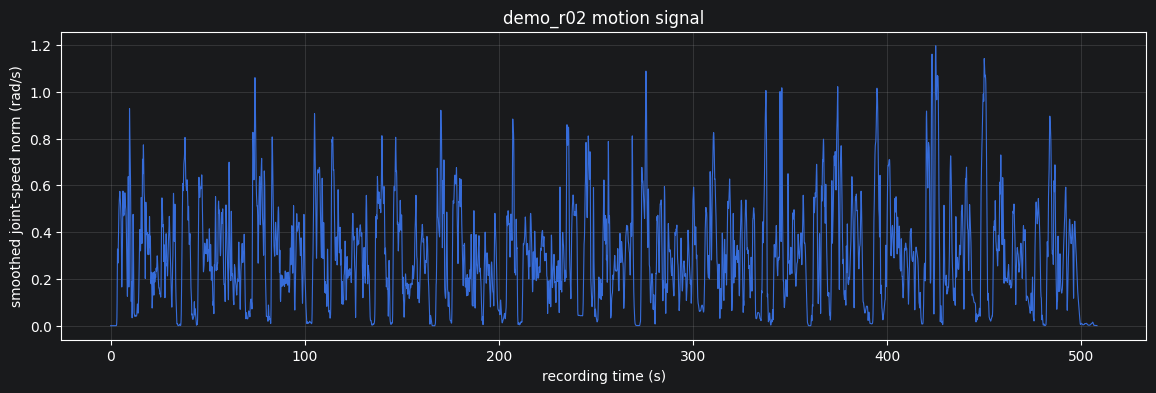

In [3]:
from experiments.bar_inspect_processing import nearest_indices

analysis_hz = 20.0
dt = 1.0 / analysis_hz
grid_abs = np.arange(np.ceil(t0 / dt) * dt, t1, dt)
grid_s = grid_abs - grid_abs[0]
joint_idx, joint_gap = nearest_indices(raw_times[JOINT_TOPIC], grid_abs)
q = raw_values[JOINT_TOPIC][joint_idx]
q_smooth = gaussian_filter1d(q, sigma=2.0, axis=0, mode='nearest')
qdot = np.gradient(q_smooth, dt, axis=0)
qdot_norm = np.linalg.norm(qdot, axis=1)
qdot_peak = np.max(np.abs(qdot), axis=1)

quantiles = [0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]
print('qdot_norm quantiles rad/s:', {str(qv): round(float(np.quantile(qdot_norm, qv)), 5) for qv in quantiles})
print('qdot_peak quantiles rad/s:', {str(qv): round(float(np.quantile(qdot_peak, qv)), 5) for qv in quantiles})
print({'grid_samples': len(grid_s), 'max_resample_gap_s': float(joint_gap.max())})

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(grid_s, qdot_norm, lw=0.8)
ax.set(xlabel='recording time (s)', ylabel='smoothed joint-speed norm (rad/s)', title='demo_r02 motion signal')
ax.grid(alpha=0.25)
plt.show()

In [4]:
def true_runs(mask):
    padded = np.r_[False, np.asarray(mask, dtype=bool), False]
    edges = np.flatnonzero(np.diff(padded.astype(np.int8)))
    return np.column_stack((edges[::2], edges[1::2]))

def stationary_runs_for_threshold(threshold, min_dwell_s=1.5, bridge_s=0.30):
    raw = qdot_norm < threshold
    bridged = binary_closing(raw, structure=np.ones(max(1, round(bridge_s * analysis_hz)), dtype=bool))
    runs = true_runs(bridged)
    runs = runs[(runs[:, 1] - runs[:, 0]) >= round(min_dwell_s * analysis_hz)]
    return runs

for threshold in (0.02, 0.03, 0.04, 0.05, 0.06, 0.08):
    runs = stationary_runs_for_threshold(threshold)
    durations = (runs[:, 1] - runs[:, 0]) / analysis_hz
    print(f'threshold={threshold:.02f}: n={len(runs)}, durations_s={np.round(durations, 2).tolist()}')

threshold=0.02: n=11, durations_s=[3.1, 2.25, 2.75, 1.75, 2.1, 2.1, 2.95, 1.95, 1.6, 1.75, 8.7]
threshold=0.03: n=11, durations_s=[3.1, 2.35, 2.85, 2.25, 2.3, 2.2, 3.05, 2.45, 1.75, 1.9, 8.75]
threshold=0.04: n=13, durations_s=[3.15, 2.45, 2.9, 2.4, 3.05, 2.3, 3.1, 2.15, 2.55, 1.85, 1.5, 2.35, 8.85]
threshold=0.05: n=16, durations_s=[3.15, 2.45, 2.95, 2.5, 3.15, 2.15, 2.4, 2.5, 3.2, 2.6, 2.6, 2.0, 1.6, 1.85, 2.4, 8.95]
threshold=0.06: n=21, durations_s=[3.2, 1.5, 2.55, 2.3, 2.5, 3.05, 2.55, 3.2, 2.25, 2.4, 2.65, 1.7, 3.25, 2.95, 2.65, 2.7, 2.75, 1.7, 2.0, 2.4, 9.05]
threshold=0.08: n=25, durations_s=[3.2, 1.65, 2.65, 3.15, 2.45, 2.6, 3.15, 2.7, 1.5, 3.4, 2.65, 2.5, 2.8, 1.75, 3.4, 3.1, 2.75, 2.8, 2.9, 1.5, 1.6, 2.45, 2.1, 2.5, 9.25]


In [5]:
stationary_threshold = 0.03
dwell_runs = stationary_runs_for_threshold(stationary_threshold, min_dwell_s=1.5)
dwell_q = np.asarray([np.median(q[a:b], axis=0) for a, b in dwell_runs])
dwell_tcp = iiwa14_fk(dwell_q)
rows = []
for i, ((a, b), pose) in enumerate(zip(dwell_runs, dwell_tcp)):
    rows.append({
        'dwell': i,
        'start_s': round(float(grid_s[a]), 2),
        'end_s': round(float(grid_s[b - 1]), 2),
        'duration_s': round(float((b - a) / analysis_hz), 2),
        'tcp_xyz': np.round(pose[:3], 4).tolist(),
    })
print(json.dumps(rows, indent=2))
print('between-dwell motion durations_s:', np.round((dwell_runs[1:, 0] - dwell_runs[:-1, 1]) / analysis_hz, 2).tolist())
print('between-dwell TCP displacement_m:', np.round(np.linalg.norm(np.diff(dwell_tcp[:, :3], axis=0), axis=1), 4).tolist())

[
  {
    "dwell": 0,
    "start_s": 0.15,
    "end_s": 3.2,
    "duration_s": 3.1,
    "tcp_xyz": [
      0.6527,
      0.0081,
      0.2087
    ]
  },
  {
    "dwell": 1,
    "start_s": 34.0,
    "end_s": 36.3,
    "duration_s": 2.35,
    "tcp_xyz": [
      0.4748,
      -0.2934,
      0.3384
    ]
  },
  {
    "dwell": 2,
    "start_s": 100.95,
    "end_s": 103.75,
    "duration_s": 2.85,
    "tcp_xyz": [
      0.3905,
      -0.3782,
      0.2928
    ]
  },
  {
    "dwell": 3,
    "start_s": 133.8,
    "end_s": 136.0,
    "duration_s": 2.25,
    "tcp_xyz": [
      0.6221,
      -0.1951,
      0.4546
    ]
  },
  {
    "dwell": 4,
    "start_s": 165.15,
    "end_s": 167.4,
    "duration_s": 2.3,
    "tcp_xyz": [
      0.5553,
      -0.2223,
      0.4208
    ]
  },
  {
    "dwell": 5,
    "start_s": 209.8,
    "end_s": 211.95,
    "duration_s": 2.2,
    "tcp_xyz": [
      0.687,
      0.3205,
      0.3071
    ]
  },
  {
    "dwell": 6,
    "start_s": 270.0,
    "end_s": 273.0,
    "du

In [6]:
from experiments.bar_inspect_processing import robust_static_pose
sys.path.insert(0, str(PROJECT_ROOT / 'robot/stage_cons_iiwa14/ros_ws/src/stage_constraint_planner/src'))
from stage_constraint_planner.optimizer import build_bar_table_task_frame, transform_pose

planner_cfg = json.loads((PROJECT_ROOT / 'robot/stage_cons_iiwa14/ros_ws/src/stage_constraint_planner/config/bar_clean_true.json').read_text())
scene_cfg = json.loads((PROJECT_ROOT / 'robot/stage_cons_iiwa14/ros_ws/src/stage_iiwa_sim/config/demo_scene.json').read_text())
bar_lock = robust_static_pose(raw_values[BAR_TOPIC], position_floor_m=0.02, local_axis=np.array([1., 0., 0.]), axis_floor_rad=np.deg2rad(8.0))
obs_lock = robust_static_pose(raw_values[OBSTACLE_TOPIC], position_floor_m=0.02)
R_track = np.asarray(scene_cfg['optitrack_to_robot']['rotation'])
t_track = np.asarray(scene_cfg['optitrack_to_robot']['translation'])
bar_robot = transform_pose(bar_lock['pose'], R_track, t_track)
obs_robot = transform_pose(obs_lock['pose'], R_track, t_track)
task_frame = build_bar_table_task_frame(bar_robot, obs_robot, planner_cfg['table_surface_point'], planner_cfg['table_normal'], planner_cfg['bar_axis_local'], planner_cfg['canonical_bar_axis'])
R_task = task_frame['rotation_world_from_task']
dwell_task_xyz = (dwell_tcp[:, :3] - task_frame['origin']) @ R_task
for i, xyz in enumerate(dwell_task_xyz):
    print(i, np.round(xyz, 4).tolist())
print({'bar_inliers': int(bar_lock['inlier'].sum()), 'bar_samples': int(len(bar_lock['inlier'])), 'bar_robot': np.round(bar_robot, 5).tolist()})

0 [-0.066, 0.015, 0.0993]
1 [0.2584, -0.1167, 0.229]
2 [0.3546, -0.1876, 0.1835]
3 [0.1396, 0.0146, 0.3452]
4 [0.1763, -0.0476, 0.3114]
5 [-0.38, 0.003, 0.1977]
6 [0.3295, -0.0484, 0.303]
7 [0.3948, -0.1746, 0.471]
8 [0.0626, -0.0024, 0.344]
9 [-0.3982, 0.0175, 0.1837]
10 [0.3578, -0.084, 0.4095]
{'bar_inliers': 117638, 'bar_samples': 117740, 'bar_robot': [0.62821, -0.05496, 0.03433, -0.47896, 0.54555, 0.52519, -0.44401]}


In [15]:
stationary_threshold = 0.05
candidate_runs = stationary_runs_for_threshold(stationary_threshold, min_dwell_s=1.8)
candidate_q = np.asarray([np.median(q[a:b], axis=0) for a, b in candidate_runs])
candidate_tcp = iiwa14_fk(candidate_q)
candidate_task = (candidate_tcp[:, :3] - task_frame['origin']) @ R_task
print('dwell_count', len(candidate_runs), 'motion_intervals', len(candidate_runs) - 1)
for i, ((a, b), xyz) in enumerate(zip(candidate_runs, candidate_task)):
    print(f'{i:2d} {grid_s[a]:7.2f}..{grid_s[b-1]:7.2f}s dwell={(b-a)/analysis_hz:4.2f}s task_xyz={np.round(xyz, 3).tolist()}')
print('interval durations_s:', np.round((candidate_runs[1:,0] - candidate_runs[:-1,1]) / analysis_hz, 2).tolist())

dwell_count 15 motion_intervals 14
 0    0.15..   3.25s dwell=3.15s task_xyz=[-0.066, 0.015, 0.099]
 1   33.95..  36.35s dwell=2.45s task_xyz=[0.258, -0.117, 0.229]
 2  100.85.. 103.75s dwell=2.95s task_xyz=[0.355, -0.188, 0.184]
 3  133.65.. 136.10s dwell=2.50s task_xyz=[0.14, 0.015, 0.345]
 4  164.35.. 167.45s dwell=3.15s task_xyz=[0.176, -0.048, 0.311]
 5  201.35.. 203.45s dwell=2.15s task_xyz=[0.186, -0.104, 0.216]
 6  209.70.. 212.05s dwell=2.40s task_xyz=[-0.38, 0.003, 0.198]
 7  240.75.. 243.20s dwell=2.50s task_xyz=[0.248, -0.005, 0.249]
 8  269.90.. 273.05s dwell=3.20s task_xyz=[0.33, -0.048, 0.303]
 9  338.75.. 341.30s dwell=2.60s task_xyz=[-0.394, 0.011, 0.215]
10  358.80.. 361.35s dwell=2.60s task_xyz=[0.395, -0.175, 0.471]
11  390.80.. 392.75s dwell=2.00s task_xyz=[0.063, -0.002, 0.344]
12  452.45.. 454.25s dwell=1.85s task_xyz=[-0.414, 0.016, 0.2]
13  479.65.. 482.00s dwell=2.40s task_xyz=[-0.399, 0.017, 0.184]
14  499.10.. 508.00s dwell=8.95s task_xyz=[0.358, -0.084, 0.4

In [16]:
tcp = iiwa14_fk(q)
task_xyz = (tcp[:, :3] - task_frame['origin']) @ R_task
endpoints = np.asarray(planner_cfg['stage_endpoint_positions_bar'])
interval_rows = []
for i in range(len(candidate_runs) - 1):
    a = int(candidate_runs[i, 1]); b = int(candidate_runs[i + 1, 0])
    xyz = task_xyz[a:b]
    distances = np.linalg.norm(xyz[:, None, :] - endpoints[None, :, :], axis=2)
    nearest_idx = np.argmin(distances, axis=0)
    min_dist = distances[nearest_idx, np.arange(len(endpoints))]
    path_len = np.linalg.norm(np.diff(xyz, axis=0), axis=1).sum()
    interval_rows.append({
        'interval': i,
        'start_s': round(float(grid_s[a]), 2),
        'end_s': round(float(grid_s[b-1]), 2),
        'duration_s': round(float((b-a)/analysis_hz), 2),
        'path_m': round(float(path_len), 3),
        'endpoint_min_m': np.round(min_dist, 3).tolist(),
        'endpoint_order': nearest_idx.tolist(),
        'min_z': round(float(xyz[:,2].min()), 3),
        'lateral_range': np.round([xyz[:,1].min(), xyz[:,1].max()], 3).tolist(),
    })
print(json.dumps(interval_rows, indent=2))

[
  {
    "interval": 0,
    "start_s": 3.3,
    "end_s": 33.9,
    "duration_s": 30.65,
    "path_m": 2.204,
    "endpoint_min_m": [
      0.014,
      0.034,
      0.004,
      0.007
    ],
    "endpoint_order": [
      371,
      453,
      508,
      552
    ],
    "min_z": 0.063,
    "lateral_range": [
      -0.157,
      0.099
    ]
  },
  {
    "interval": 1,
    "start_s": 36.4,
    "end_s": 100.8,
    "duration_s": 64.45,
    "path_m": 4.996,
    "endpoint_min_m": [
      0.006,
      0.004,
      0.002,
      0.013
    ],
    "endpoint_order": [
      1007,
      447,
      1194,
      1229
    ],
    "min_z": 0.064,
    "lateral_range": [
      -0.184,
      0.12
    ]
  },
  {
    "interval": 2,
    "start_s": 103.8,
    "end_s": 133.6,
    "duration_s": 29.85,
    "path_m": 2.616,
    "endpoint_min_m": [
      0.01,
      0.026,
      0.002,
      0.012
    ],
    "endpoint_order": [
      311,
      404,
      470,
      509
    ],
    "min_z": 0.067,
    "lateral_range":

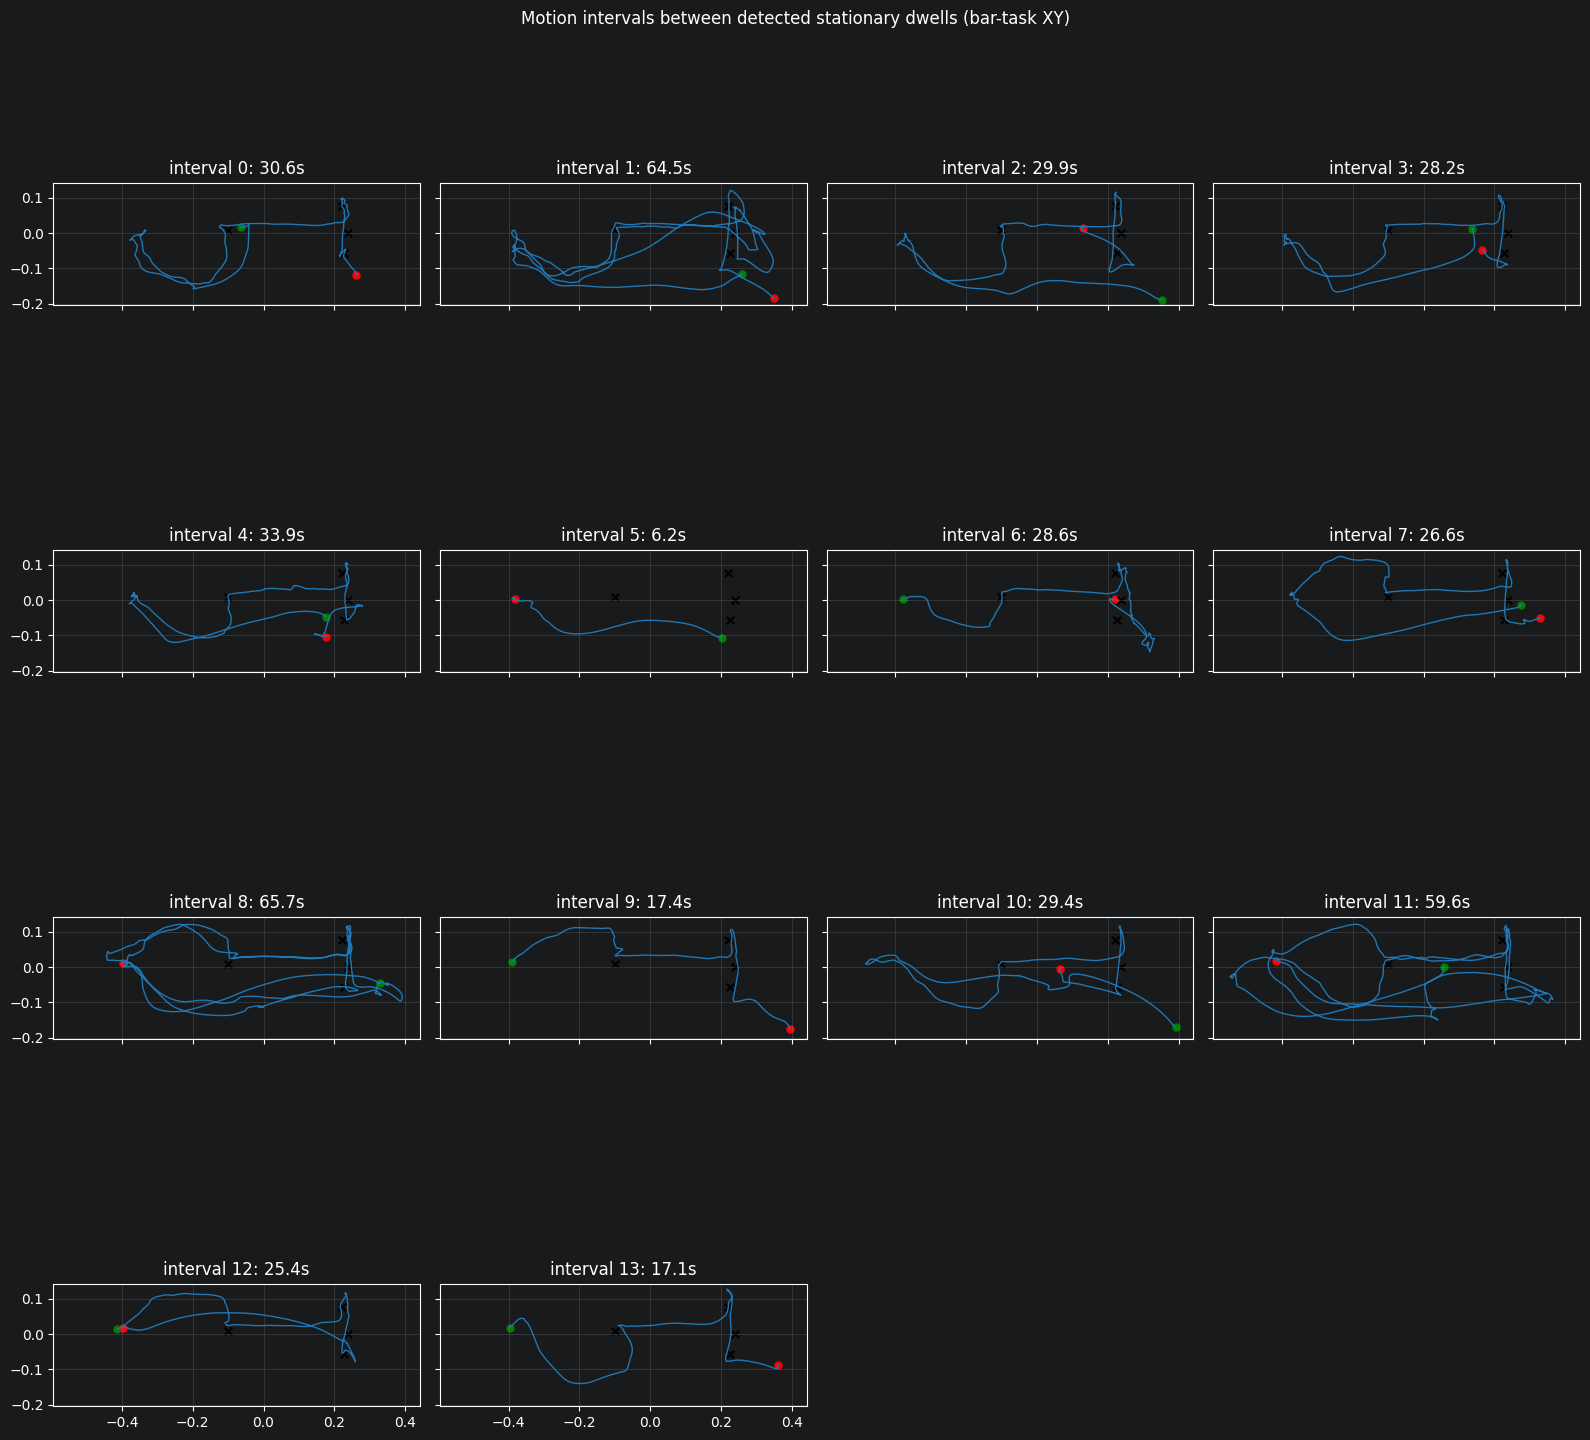

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16), sharex=True, sharey=True)
for ax in axes.flat:
    ax.set_visible(False)
for i in range(len(candidate_runs)-1):
    ax = axes.flat[i]; ax.set_visible(True)
    a = int(candidate_runs[i,1]); b = int(candidate_runs[i+1,0])
    xyz = task_xyz[a:b]
    ax.plot(xyz[:,0], xyz[:,1], lw=1.0, color='tab:blue')
    ax.scatter(xyz[0,0], xyz[0,1], c='green', s=25, label='start')
    ax.scatter(xyz[-1,0], xyz[-1,1], c='red', s=25, label='end')
    ax.scatter(endpoints[:,0], endpoints[:,1], c='black', marker='x', s=30)
    ax.set_title(f'interval {i}: {(b-a)/analysis_hz:.1f}s')
    ax.grid(alpha=0.25)
    ax.set_aspect('equal', adjustable='box')
fig.suptitle('Motion intervals between detected stationary dwells (bar-task XY)')
fig.tight_layout()
plt.show()

In [17]:
selected_intervals = []
excluded_intervals = []
for row in interval_rows:
    order = np.asarray(row['endpoint_order'])
    distances = np.asarray(row['endpoint_min_m'])
    ordered = bool(order[0] < min(order[1], order[2]) and max(order[1], order[2]) < order[3])
    close = bool(np.max(distances) <= 0.06)
    long_enough = bool(row['duration_s'] >= 12.0)
    decision = {**row, 'ordered_endpoint_visit': ordered, 'all_endpoints_within_6cm': close}
    if ordered and close and long_enough:
        selected_intervals.append(decision)
    else:
        reasons = []
        if not ordered: reasons.append('endpoint order inconsistent with BarClean')
        if not close: reasons.append('does not reach all task endpoints')
        if not long_enough: reasons.append('too short')
        decision['exclusion_reasons'] = reasons
        excluded_intervals.append(decision)
print('selected_demo_count =', len(selected_intervals))
print('selected intervals =', [row['interval'] for row in selected_intervals])
print('durations_s =', [row['duration_s'] for row in selected_intervals])
print('excluded =', {row['interval']: row['exclusion_reasons'] for row in excluded_intervals})

selected_demo_count = 10
selected intervals = [0, 2, 3, 4, 6, 7, 9, 10, 12, 13]
durations_s = [30.65, 29.85, 28.2, 33.85, 28.65, 26.65, 17.45, 29.4, 25.35, 17.05]
excluded = {1: ['endpoint order inconsistent with BarClean'], 5: ['endpoint order inconsistent with BarClean', 'does not reach all task endpoints', 'too short'], 8: ['endpoint order inconsistent with BarClean'], 11: ['endpoint order inconsistent with BarClean']}


In [18]:
OUTPUT.mkdir(parents=True, exist_ok=True)
per_demo_dir = OUTPUT / 'demos'
per_demo_dir.mkdir(parents=True, exist_ok=True)
bar_idx, bar_gap = nearest_indices(raw_times[BAR_TOPIC], grid_abs)
obs_idx, obs_gap = nearest_indices(raw_times[OBSTACLE_TOPIC], grid_abs)
bar_grid = raw_values[BAR_TOPIC][bar_idx]
obs_grid = raw_values[OBSTACLE_TOPIC][obs_idx]

aggregate = {key: [] for key in ('timestamps_s', 'demo_time_s', 'joint_positions', 'joint_velocity', 'flange_pose', 'bar_pose_optitrack', 'obstacle_pose_optitrack', 'demo_id')}
aggregate_bounds = []
demo_manifest = []
offset = 0
for demo_id, selected in enumerate(selected_intervals):
    interval = int(selected['interval'])
    a = int(candidate_runs[interval, 1])
    b = int(candidate_runs[interval + 1, 0])
    sl = slice(a, b)
    recording_time = grid_s[sl]
    local_time = recording_time - recording_time[0]
    arrays = {
        'schema_version': np.asarray(1, dtype=np.int64),
        'demo_id': np.asarray(demo_id, dtype=np.int64),
        'source_interval_id': np.asarray(interval, dtype=np.int64),
        'timestamps_s': local_time,
        'recording_timestamps_s': recording_time,
        'joint_positions': q[sl],
        'joint_velocity': qdot[sl],
        'flange_pose': tcp[sl],
        'bar_pose_optitrack': bar_grid[sl],
        'obstacle_pose_optitrack': obs_grid[sl],
        'sampling_hz': np.asarray(analysis_hz),
        'source_bag': np.asarray(str(BAG.relative_to(PROJECT_ROOT))),
        'optitrack_to_robot_rotation': R_track,
        'optitrack_to_robot_translation': t_track,
    }
    demo_path = per_demo_dir / f'demo_{demo_id:02d}.npz'
    np.savez_compressed(demo_path, **arrays)
    n = b - a
    aggregate_bounds.append([offset, offset + n])
    aggregate['timestamps_s'].append(recording_time)
    aggregate['demo_time_s'].append(local_time)
    aggregate['joint_positions'].append(q[sl])
    aggregate['joint_velocity'].append(qdot[sl])
    aggregate['flange_pose'].append(tcp[sl])
    aggregate['bar_pose_optitrack'].append(bar_grid[sl])
    aggregate['obstacle_pose_optitrack'].append(obs_grid[sl])
    aggregate['demo_id'].append(np.full(n, demo_id, dtype=np.int64))
    demo_manifest.append({
        'demo_id': demo_id,
        'source_interval_id': interval,
        'start_s': round(float(recording_time[0]), 3),
        'end_s': round(float(recording_time[-1]), 3),
        'duration_s': round(float(local_time[-1]), 3),
        'samples': int(n),
        'file': str(demo_path.relative_to(OUTPUT)),
        'dwell_before_s': round(float((candidate_runs[interval,1]-candidate_runs[interval,0])/analysis_hz), 3),
        'dwell_after_s': round(float((candidate_runs[interval+1,1]-candidate_runs[interval+1,0])/analysis_hz), 3),
        'endpoint_min_distance_m': selected['endpoint_min_m'],
    })
    offset += n

aggregate_arrays = {key: np.concatenate(value, axis=0) for key, value in aggregate.items()}
aggregate_arrays.update({
    'schema_version': np.asarray(1, dtype=np.int64),
    'demo_bounds_indices': np.asarray(aggregate_bounds, dtype=np.int64),
    'sampling_hz': np.asarray(analysis_hz),
    'source_bag': np.asarray(str(BAG.relative_to(PROJECT_ROOT))),
    'locked_bar_pose_optitrack': bar_lock['pose'],
    'reference_obstacle_pose_optitrack': obs_lock['pose'],
    'optitrack_to_robot_rotation': R_track,
    'optitrack_to_robot_translation': t_track,
    'task_endpoint_positions_bar': endpoints,
})
aggregate_path = OUTPUT / 'demo_r02_10_demos_20hz.npz'
np.savez_compressed(aggregate_path, **aggregate_arrays)

manifest = {
    'schema_version': 1,
    'source_bag': str(BAG.relative_to(PROJECT_ROOT)),
    'source_duration_s': round(float(grid_s[-1]), 3),
    'selected_demo_count': len(selected_intervals),
    'sampling_hz': analysis_hz,
    'segmentation': {
        'motion_signal': 'L2 norm of 20 Hz joint velocity after Gaussian position smoothing (sigma=0.1 s)',
        'stationary_threshold_rad_s': stationary_threshold,
        'stationary_gap_bridge_s': 0.30,
        'minimum_stationary_dwell_s': 1.8,
        'boundary_policy': 'exclude stationary dwell; keep motion between dwell end and next dwell start',
        'task_classifier': 'visit all four BarClean endpoints within 0.06 m in forward stage order; stage-2/stage-3 nearest order may swap because they are spatially adjacent',
    },
    'selected_source_intervals': [int(row['interval']) for row in selected_intervals],
    'excluded_intervals': excluded_intervals,
    'outputs': {
        'aggregate_npz': aggregate_path.name,
        'per_demo_directory': 'demos',
        'segmentation_preview': 'segmentation_preview.png',
    },
    'demos': demo_manifest,
    'quality': {
        'raw_joint_rate_hz': summary[JOINT_TOPIC]['rate_hz'],
        'analysis_grid_max_joint_gap_s': float(joint_gap.max()),
        'analysis_grid_max_bar_gap_s': float(bar_gap.max()),
        'analysis_grid_max_obstacle_gap_s': float(obs_gap.max()),
        'all_exported_values_finite': bool(all(np.isfinite(v).all() for k, v in aggregate_arrays.items() if isinstance(v, np.ndarray) and v.dtype.kind in 'fiu')),
    },
}
(OUTPUT / 'manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
print({'aggregate': str(aggregate_path), 'demos': len(demo_manifest), 'samples': int(offset), 'durations_s': [d['duration_s'] for d in demo_manifest]})

{'aggregate': '/home/baiyu/LearnStageConstraints/robot/stage_cons_iiwa14/data/processed/demo_r02_auto/demo_r02_10_demos_20hz.npz', 'demos': 10, 'samples': 5342, 'durations_s': [30.6, 29.8, 28.15, 33.8, 28.6, 26.6, 17.4, 29.35, 25.3, 17.0]}


In [19]:
demo_bar_locks = []
demo_obstacle_locks = []
tracker_quality = []
for entry in demo_manifest:
    absolute_start = float(grid_abs[0] + entry['start_s'])
    absolute_end = float(grid_abs[0] + entry['end_s'])
    bar_mask = (raw_times[BAR_TOPIC] >= absolute_start) & (raw_times[BAR_TOPIC] <= absolute_end)
    obs_mask = (raw_times[OBSTACLE_TOPIC] >= absolute_start) & (raw_times[OBSTACLE_TOPIC] <= absolute_end)
    bar_demo = robust_static_pose(raw_values[BAR_TOPIC][bar_mask], position_floor_m=0.02, local_axis=np.array([1., 0., 0.]), axis_floor_rad=np.deg2rad(8.0))
    obs_demo = robust_static_pose(raw_values[OBSTACLE_TOPIC][obs_mask], position_floor_m=0.02)
    demo_bar_locks.append(bar_demo['pose'])
    demo_obstacle_locks.append(obs_demo['pose'])
    bar_times = raw_times[BAR_TOPIC][bar_mask]
    obs_times = raw_times[OBSTACLE_TOPIC][obs_mask]
    tracker_quality.append({
        'demo_id': entry['demo_id'],
        'bar_samples': int(len(bar_times)),
        'obstacle_samples': int(len(obs_times)),
        'bar_max_gap_s': round(float(np.max(np.diff(bar_times))) if len(bar_times) > 1 else math.inf, 4),
        'obstacle_max_gap_s': round(float(np.max(np.diff(obs_times))) if len(obs_times) > 1 else math.inf, 4),
    })
    path = OUTPUT / entry['file']
    with np.load(path) as loaded:
        payload = {key: loaded[key] for key in loaded.files}
    payload['locked_bar_pose_optitrack'] = bar_demo['pose']
    payload['locked_obstacle_pose_optitrack'] = obs_demo['pose']
    payload['scene_pose_policy'] = np.asarray('per_demo_robust_static_lock')
    np.savez_compressed(path, **payload)

with np.load(aggregate_path) as loaded:
    aggregate_payload = {key: loaded[key] for key in loaded.files}
aggregate_payload['demo_bar_poses_optitrack'] = np.asarray(demo_bar_locks)
aggregate_payload['demo_obstacle_poses_optitrack'] = np.asarray(demo_obstacle_locks)
aggregate_payload['scene_pose_policy'] = np.asarray('per_demo_robust_static_lock')
np.savez_compressed(aggregate_path, **aggregate_payload)
manifest['scene_pose_policy'] = 'per_demo_robust_static_lock; use locked scene poses for downstream feature computation'
manifest['tracker_quality_per_demo'] = tracker_quality
(OUTPUT / 'manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
print(json.dumps(tracker_quality, indent=2))

[
  {
    "demo_id": 0,
    "bar_samples": 7625,
    "obstacle_samples": 7643,
    "bar_max_gap_s": 0.0554,
    "obstacle_max_gap_s": 0.0401
  },
  {
    "demo_id": 1,
    "bar_samples": 6937,
    "obstacle_samples": 7002,
    "bar_max_gap_s": 1.1046,
    "obstacle_max_gap_s": 1.1047
  },
  {
    "demo_id": 2,
    "bar_samples": 6975,
    "obstacle_samples": 7029,
    "bar_max_gap_s": 0.1321,
    "obstacle_max_gap_s": 0.0213
  },
  {
    "demo_id": 3,
    "bar_samples": 5467,
    "obstacle_samples": 5526,
    "bar_max_gap_s": 9.9445,
    "obstacle_max_gap_s": 9.9446
  },
  {
    "demo_id": 4,
    "bar_samples": 6518,
    "obstacle_samples": 6518,
    "bar_max_gap_s": 0.8603,
    "obstacle_max_gap_s": 0.8602
  },
  {
    "demo_id": 5,
    "bar_samples": 6632,
    "obstacle_samples": 6642,
    "bar_max_gap_s": 0.0389,
    "obstacle_max_gap_s": 0.0362
  },
  {
    "demo_id": 6,
    "bar_samples": 4345,
    "obstacle_samples": 4350,
    "bar_max_gap_s": 0.0242,
    "obstacle_max_gap_s": 0.

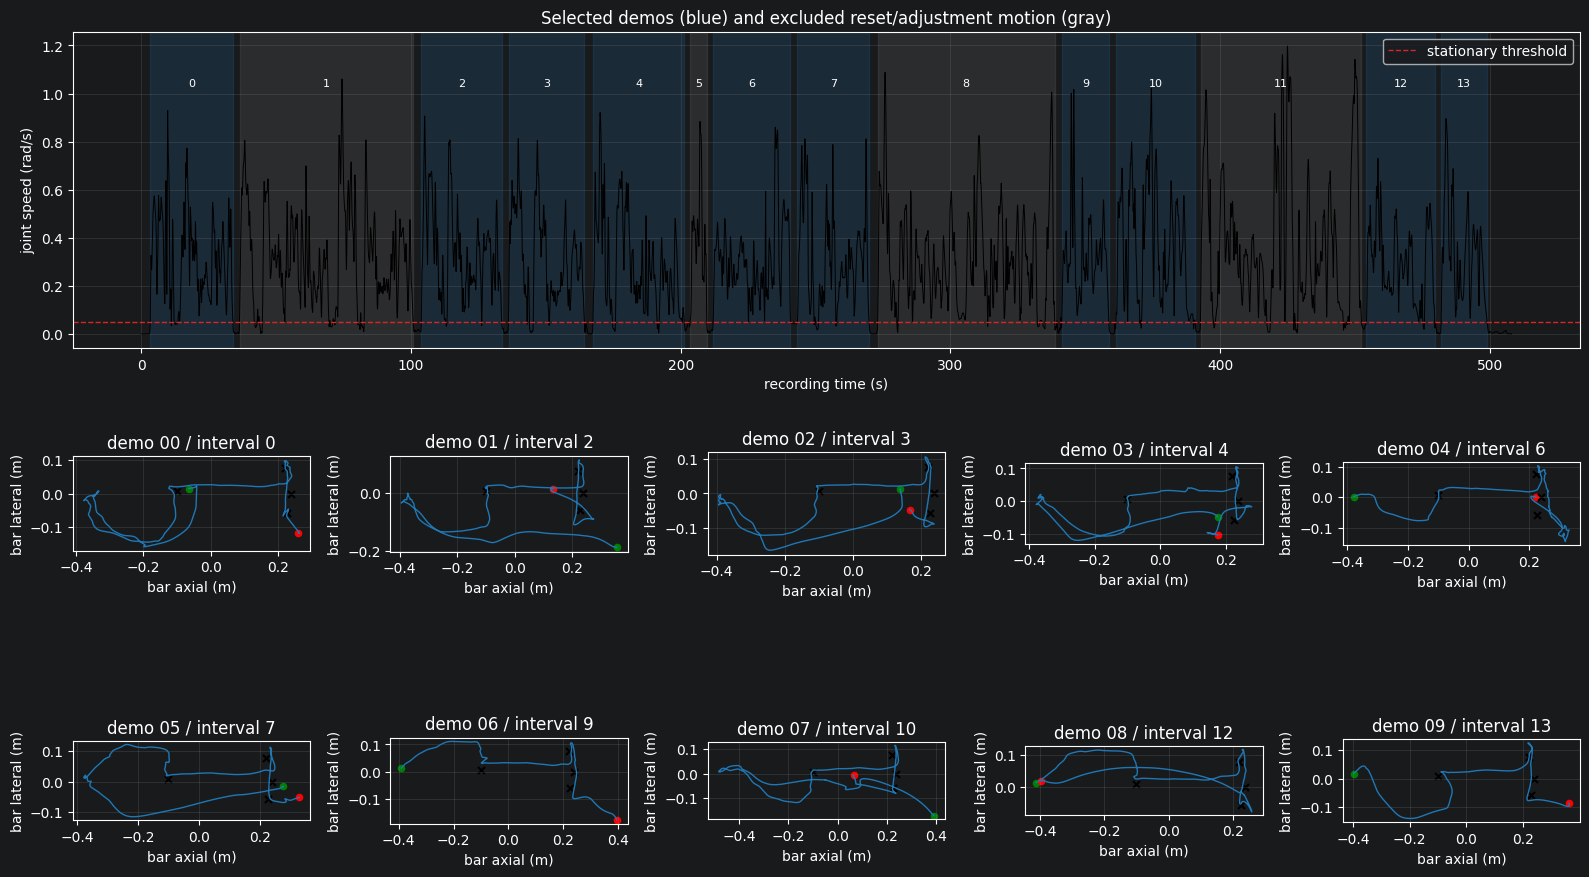

/home/baiyu/LearnStageConstraints/robot/stage_cons_iiwa14/data/processed/demo_r02_auto/segmentation_preview.png


In [20]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(4, 5, height_ratios=[1.3, 1, 1, 1])
ax_speed = fig.add_subplot(gs[0, :])
ax_speed.plot(grid_s, qdot_norm, color='black', lw=0.7)
ax_speed.axhline(stationary_threshold, color='tab:red', ls='--', lw=1, label='stationary threshold')
selected_ids = {int(row['interval']) for row in selected_intervals}
for i in range(len(candidate_runs)-1):
    a = int(candidate_runs[i,1]); b = int(candidate_runs[i+1,0])
    color = 'tab:blue' if i in selected_ids else 'tab:gray'
    ax_speed.axvspan(grid_s[a], grid_s[b-1], color=color, alpha=0.18)
    ax_speed.text((grid_s[a]+grid_s[b-1])/2, 1.02, str(i), ha='center', va='bottom', fontsize=8)
ax_speed.set(xlabel='recording time (s)', ylabel='joint speed (rad/s)', title='Selected demos (blue) and excluded reset/adjustment motion (gray)')
ax_speed.grid(alpha=0.2); ax_speed.legend(loc='upper right')

for demo_id, selected in enumerate(selected_intervals):
    ax = fig.add_subplot(gs[1 + demo_id // 5, demo_id % 5])
    interval = int(selected['interval'])
    a = int(candidate_runs[interval,1]); b = int(candidate_runs[interval+1,0])
    xyz = task_xyz[a:b]
    ax.plot(xyz[:,0], xyz[:,1], color='tab:blue', lw=1)
    ax.scatter(xyz[0,0], xyz[0,1], c='green', s=20)
    ax.scatter(xyz[-1,0], xyz[-1,1], c='red', s=20)
    ax.scatter(endpoints[:,0], endpoints[:,1], c='black', marker='x', s=25)
    ax.set_title(f'demo {demo_id:02d} / interval {interval}')
    ax.set_aspect('equal', adjustable='box'); ax.grid(alpha=0.2)
    ax.set_xlabel('bar axial (m)'); ax.set_ylabel('bar lateral (m)')
fig.tight_layout()
preview_path = OUTPUT / 'segmentation_preview.png'
fig.savefig(preview_path, dpi=160, bbox_inches='tight')
plt.show()
print(preview_path)

In [21]:
saved_manifest = json.loads((OUTPUT / 'manifest.json').read_text())
with np.load(aggregate_path) as saved:
    saved_shapes = {key: saved[key].shape for key in saved.files}
    bounds = saved['demo_bounds_indices']
    ids = saved['demo_id']
    finite = all(np.isfinite(saved[key]).all() for key in saved.files if saved[key].dtype.kind in 'fiu')
    assert bounds.shape == (10, 2)
    assert saved['demo_bar_poses_optitrack'].shape == (10, 7)
    assert saved['demo_obstacle_poses_optitrack'].shape == (10, 7)
    assert finite
    for demo_id, (a, b) in enumerate(bounds):
        assert np.all(ids[a:b] == demo_id)
        assert b > a
per_demo_files = sorted((OUTPUT / 'demos').glob('demo_*.npz'))
assert len(per_demo_files) == 10
assert saved_manifest['selected_demo_count'] == 10
print({
    'validated_demo_count': len(per_demo_files),
    'aggregate_samples': int(saved_shapes['joint_positions'][0]),
    'aggregate_shape': saved_shapes['joint_positions'],
    'all_numeric_values_finite': finite,
    'output_size_mb': round(sum(path.stat().st_size for path in OUTPUT.rglob('*') if path.is_file()) / 1e6, 3),
    'files': [path.name for path in per_demo_files],
})

{'validated_demo_count': 10, 'aggregate_samples': 5342, 'aggregate_shape': (5342, 7), 'all_numeric_values_finite': True, 'output_size_mb': 3.307, 'files': ['demo_00.npz', 'demo_01.npz', 'demo_02.npz', 'demo_03.npz', 'demo_04.npz', 'demo_05.npz', 'demo_06.npz', 'demo_07.npz', 'demo_08.npz', 'demo_09.npz']}


## Corrected start-anchored segmentation

The earlier interval classifier was invalid because a long interval could contain a complete task plus the reset to the next start. Corrected boundaries require every demo to begin from a stationary pose near the obstacle on the left side of the bar. The end is the first post-task dwell after visiting the four task endpoint regions in forward order.

In [26]:
boundary_speed_threshold = 0.08
boundary_min_dwell_s = 1.0
boundary_runs = stationary_runs_for_threshold(
    boundary_speed_threshold,
    min_dwell_s=boundary_min_dwell_s,
)
boundary_q = np.asarray([np.median(q[a:b], axis=0) for a, b in boundary_runs])
boundary_tcp = iiwa14_fk(boundary_q)
boundary_task = (boundary_tcp[:, :3] - task_frame['origin']) @ R_task
start_mask = (
    (boundary_task[:, 0] < -0.34)
    & (np.abs(boundary_task[:, 1] - obs_task[1]) < 0.10)
    & (boundary_task[:, 2] > 0.10)
    & (boundary_task[:, 2] < 0.26)
    & (np.linalg.norm(boundary_task[:, :2] - obs_task[:2], axis=1) < 0.32)
)
start_run_indices = np.flatnonzero(start_mask)
# The dwell run ends exactly at the first sustained-moving sample.
demo_starts = np.asarray([boundary_runs[i, 1] for i in start_run_indices], dtype=int)

endpoint_tolerance_m = 0.06
stop_confirmation_window_s = 0.50
stop_speed_threshold = boundary_speed_threshold
stop_confirmation_samples = max(
    1,
    int(round(stop_confirmation_window_s * analysis_hz)),
)
future_mean_speed = np.convolve(
    qdot_norm,
    np.ones(stop_confirmation_samples) / stop_confirmation_samples,
    mode='valid',
)

demo_bounds = []
endpoint_hits = []
for demo_id, start in enumerate(demo_starts):
    search_stop = (
        int(demo_starts[demo_id + 1])
        if demo_id + 1 < len(demo_starts)
        else len(grid_s)
    )
    cursor = int(start)
    hits = []
    for endpoint in endpoints:
        local_hits = np.flatnonzero(
            np.linalg.norm(task_xyz[cursor:search_stop] - endpoint, axis=1)
            <= endpoint_tolerance_m
        )
        if len(local_hits) == 0:
            raise RuntimeError(
                f'demo {demo_id}: did not visit every endpoint before the next start'
            )
        cursor += int(local_hits[0])
        hits.append(cursor)

    confirmation_stop = min(search_stop, len(future_mean_speed))
    stop_candidates = np.flatnonzero(
        (qdot_norm[cursor:confirmation_stop] < stop_speed_threshold)
        & (
            future_mean_speed[cursor:confirmation_stop]
            < stop_speed_threshold
        )
    )
    if len(stop_candidates) == 0:
        raise RuntimeError(
            f'demo {demo_id}: no confirmed stop before the next start'
        )
    # This is the first stationary sample. The exported half-open slice [start, end)
    # excludes it, while retaining every preceding deceleration sample.
    end = cursor + int(stop_candidates[0])
    if end <= start:
        raise RuntimeError(f'demo {demo_id}: invalid bounds {start}:{end}')
    demo_bounds.append((int(start), int(end)))
    endpoint_hits.append(hits)

demo_bounds = np.asarray(demo_bounds, dtype=int)
endpoint_hits = np.asarray(endpoint_hits, dtype=int)
print('corrected_demo_count =', len(demo_bounds))
for demo_id, ((a, b), hits) in enumerate(zip(demo_bounds, endpoint_hits)):
    print(
        f'{demo_id:02d}',
        f'start={grid_s[a]:.2f}s',
        f'complete={grid_s[hits[-1]]:.2f}s',
        f'last_motion={grid_s[b - 1]:.2f}s',
        f'first_stationary={grid_s[b]:.2f}s',
        f'duration={(b-a)/analysis_hz:.2f}s',
        f'edge_speed={qdot_norm[a]:.3f}/{qdot_norm[b-1]:.3f}rad/s',
    )

corrected_demo_count = 13
00 start=13.70s complete=30.05s last_motion=33.80s first_stationary=33.85s duration=20.15s edge_speed=0.081/0.089rad/s
01 start=44.95s complete=65.20s last_motion=69.45s first_stationary=69.50s duration=24.55s edge_speed=0.104/0.081rad/s
02 start=82.70s complete=97.15s last_motion=100.65s first_stationary=100.70s duration=18.00s edge_speed=0.134/0.081rad/s
03 start=113.45s complete=128.55s last_motion=133.45s first_stationary=133.50s duration=20.05s edge_speed=0.107/0.100rad/s
04 start=145.35s complete=160.65s last_motion=164.10s first_stationary=164.15s duration=18.80s edge_speed=0.083/0.090rad/s
05 start=175.85s complete=194.50s last_motion=199.40s first_stationary=199.45s duration=23.60s edge_speed=0.082/0.086rad/s
06 start=212.15s complete=230.60s last_motion=240.60s first_stationary=240.65s duration=28.50s edge_speed=0.093/0.089rad/s
07 start=251.20s complete=266.85s last_motion=269.70s first_stationary=269.75s duration=18.55s edge_speed=0.098/0.083rad/s


In [27]:
OUTPUT.mkdir(parents=True, exist_ok=True)
per_demo_dir = OUTPUT / 'demos'
per_demo_dir.mkdir(parents=True, exist_ok=True)

# Replace the earlier automatic extraction so stale 10-demo files cannot be mistaken for corrected data.
for stale in per_demo_dir.glob('demo_*.npz'):
    stale.unlink()
for stale in OUTPUT.glob('demo_r02_*_demos_20hz.npz'):
    stale.unlink()

bar_idx, bar_gap = nearest_indices(raw_times[BAR_TOPIC], grid_abs)
obs_idx, obs_gap = nearest_indices(raw_times[OBSTACLE_TOPIC], grid_abs)
bar_grid = raw_values[BAR_TOPIC][bar_idx]
obs_grid = raw_values[OBSTACLE_TOPIC][obs_idx]

aggregate_keys = (
    'timestamps_s',
    'demo_time_s',
    'joint_positions',
    'joint_velocity',
    'flange_pose',
    'bar_pose_optitrack',
    'obstacle_pose_optitrack',
    'demo_id',
)
aggregate = {key: [] for key in aggregate_keys}
aggregate_bounds = []
demo_manifest = []
demo_bar_locks = []
demo_obstacle_locks = []
tracker_quality = []
offset = 0

for demo_id, ((a, b), hits, start_run_id) in enumerate(
    zip(demo_bounds, endpoint_hits, start_run_indices)
):
    sl = slice(a, b)
    recording_time = grid_s[sl]
    local_time = recording_time - recording_time[0]
    absolute_start = float(grid_abs[a])
    absolute_end = float(grid_abs[b - 1])
    bar_mask = (
        (raw_times[BAR_TOPIC] >= absolute_start)
        & (raw_times[BAR_TOPIC] <= absolute_end)
    )
    obs_mask = (
        (raw_times[OBSTACLE_TOPIC] >= absolute_start)
        & (raw_times[OBSTACLE_TOPIC] <= absolute_end)
    )
    bar_demo = robust_static_pose(
        raw_values[BAR_TOPIC][bar_mask],
        position_floor_m=0.02,
        local_axis=np.array([1.0, 0.0, 0.0]),
        axis_floor_rad=np.deg2rad(8.0),
    )
    obs_demo = robust_static_pose(
        raw_values[OBSTACLE_TOPIC][obs_mask],
        position_floor_m=0.02,
    )
    demo_bar_locks.append(bar_demo['pose'])
    demo_obstacle_locks.append(obs_demo['pose'])
    bar_times = raw_times[BAR_TOPIC][bar_mask]
    obs_times = raw_times[OBSTACLE_TOPIC][obs_mask]
    tracker_quality.append({
        'demo_id': demo_id,
        'bar_samples': int(len(bar_times)),
        'obstacle_samples': int(len(obs_times)),
        'bar_max_gap_s': round(float(np.max(np.diff(bar_times))) if len(bar_times) > 1 else math.inf, 4),
        'obstacle_max_gap_s': round(float(np.max(np.diff(obs_times))) if len(obs_times) > 1 else math.inf, 4),
    })

    arrays = {
        'schema_version': np.asarray(2, dtype=np.int64),
        'demo_id': np.asarray(demo_id, dtype=np.int64),
        'source_start_dwell_id': np.asarray(int(start_run_id), dtype=np.int64),
        'timestamps_s': local_time,
        'recording_timestamps_s': recording_time,
        'joint_positions': q[sl],
        'joint_velocity': qdot[sl],
        'flange_pose': tcp[sl],
        'bar_pose_optitrack': bar_grid[sl],
        'obstacle_pose_optitrack': obs_grid[sl],
        'sampling_hz': np.asarray(analysis_hz),
        'source_bag': np.asarray(str(BAG.relative_to(PROJECT_ROOT))),
        'locked_bar_pose_optitrack': bar_demo['pose'],
        'locked_obstacle_pose_optitrack': obs_demo['pose'],
        'scene_pose_policy': np.asarray('per_demo_robust_static_lock'),
        'optitrack_to_robot_rotation': R_track,
        'optitrack_to_robot_translation': t_track,
        'task_frame_origin_robot': np.asarray(task_frame['origin']),
        'task_frame_rotation_world_from_task': R_task,
    }
    demo_path = per_demo_dir / f'demo_{demo_id:02d}.npz'
    np.savez_compressed(demo_path, **arrays)

    n = b - a
    aggregate_bounds.append([offset, offset + n])
    aggregate['timestamps_s'].append(recording_time)
    aggregate['demo_time_s'].append(local_time)
    aggregate['joint_positions'].append(q[sl])
    aggregate['joint_velocity'].append(qdot[sl])
    aggregate['flange_pose'].append(tcp[sl])
    aggregate['bar_pose_optitrack'].append(bar_grid[sl])
    aggregate['obstacle_pose_optitrack'].append(obs_grid[sl])
    aggregate['demo_id'].append(np.full(n, demo_id, dtype=np.int64))
    start_dwell_a, start_dwell_b = boundary_runs[start_run_id]
    demo_manifest.append({
        'demo_id': demo_id,
        'start_s': round(float(recording_time[0]), 3),
        'task_complete_s': round(float(grid_s[hits[-1]]), 3),
        'end_s': round(float(recording_time[-1]), 3),
        'duration_s': round(float(local_time[-1]), 3),
        'samples': int(n),
        'file': str(demo_path.relative_to(OUTPUT)),
        'start_dwell_s': round(float((start_dwell_b - start_dwell_a) / analysis_hz), 3),
        'endpoint_hit_times_s': np.round(grid_s[hits], 3).tolist(),
        'start_task_xyz_m': np.round(task_xyz[a], 5).tolist(),
        'end_task_xyz_m': np.round(task_xyz[b - 1], 5).tolist(),
    })
    offset += n

aggregate_arrays = {
    key: np.concatenate(values, axis=0)
    for key, values in aggregate.items()
}
aggregate_arrays.update({
    'schema_version': np.asarray(2, dtype=np.int64),
    'demo_bounds_indices': np.asarray(aggregate_bounds, dtype=np.int64),
    'sampling_hz': np.asarray(analysis_hz),
    'source_bag': np.asarray(str(BAG.relative_to(PROJECT_ROOT))),
    'demo_bar_poses_optitrack': np.asarray(demo_bar_locks),
    'demo_obstacle_poses_optitrack': np.asarray(demo_obstacle_locks),
    'scene_pose_policy': np.asarray('per_demo_robust_static_lock'),
    'optitrack_to_robot_rotation': R_track,
    'optitrack_to_robot_translation': t_track,
    'task_frame_origin_robot': np.asarray(task_frame['origin']),
    'task_frame_rotation_world_from_task': R_task,
    'task_endpoint_positions_bar': endpoints,
})
aggregate_path = OUTPUT / f'demo_r02_{len(demo_bounds)}_demos_20hz.npz'
np.savez_compressed(aggregate_path, **aggregate_arrays)

manifest = {
    'schema_version': 2,
    'source_bag': str(BAG.relative_to(PROJECT_ROOT)),
    'source_duration_s': round(float(grid_s[-1]), 3),
    'selected_demo_count': int(len(demo_bounds)),
    'sampling_hz': analysis_hz,
    'segmentation': {
        'motion_signal': 'L2 norm of 20 Hz joint velocity after Gaussian position smoothing (sigma=0.1 s)',
        'start_anchor': 'end of a stationary dwell at the known BarClean start region: obstacle-near and bar-left in the bar task frame',
        'start_stationary_threshold_rad_s': boundary_speed_threshold,
        'minimum_start_dwell_s': boundary_min_dwell_s,
        'task_completion': 'visit all four BarClean endpoints within 0.06 m in forward order',
        'end_boundary': 'half-open cut at the first below-threshold sample whose following 0.50 s mean confirms stopping; stationary sample excluded',
        'motion_boundary_speed_threshold_rad_s': stop_speed_threshold,
        'stop_confirmation_window_s': stop_confirmation_window_s,
        'return_to_next_start_included': False,
    },
    'outputs': {
        'aggregate_npz': aggregate_path.name,
        'per_demo_directory': 'demos',
        'segmentation_preview': 'segmentation_preview.png',
    },
    'scene_pose_policy': 'per_demo_robust_static_lock; use locked scene poses for downstream feature computation',
    'tracker_quality_per_demo': tracker_quality,
    'demos': demo_manifest,
    'quality': {
        'raw_joint_rate_hz': summary[JOINT_TOPIC]['rate_hz'],
        'analysis_grid_max_joint_gap_s': float(joint_gap.max()),
        'analysis_grid_max_bar_gap_s': float(bar_gap.max()),
        'analysis_grid_max_obstacle_gap_s': float(obs_gap.max()),
        'all_exported_values_finite': bool(
            all(
                np.isfinite(value).all()
                for value in aggregate_arrays.values()
                if isinstance(value, np.ndarray) and value.dtype.kind in 'fiu'
            )
        ),
    },
}
(OUTPUT / 'manifest.json').write_text(
    json.dumps(manifest, indent=2),
    encoding='utf-8',
)
print({
    'aggregate': str(aggregate_path),
    'demos': len(demo_manifest),
    'samples': int(offset),
    'durations_s': [entry['duration_s'] for entry in demo_manifest],
})

{'aggregate': '/home/baiyu/LearnStageConstraints/robot/stage_cons_iiwa14/data/processed/demo_r02_auto/demo_r02_13_demos_20hz.npz', 'demos': 13, 'samples': 5210, 'durations_s': [20.1, 24.5, 17.95, 20.0, 18.75, 23.55, 28.45, 18.5, 17.25, 18.65, 16.65, 18.85, 16.65]}


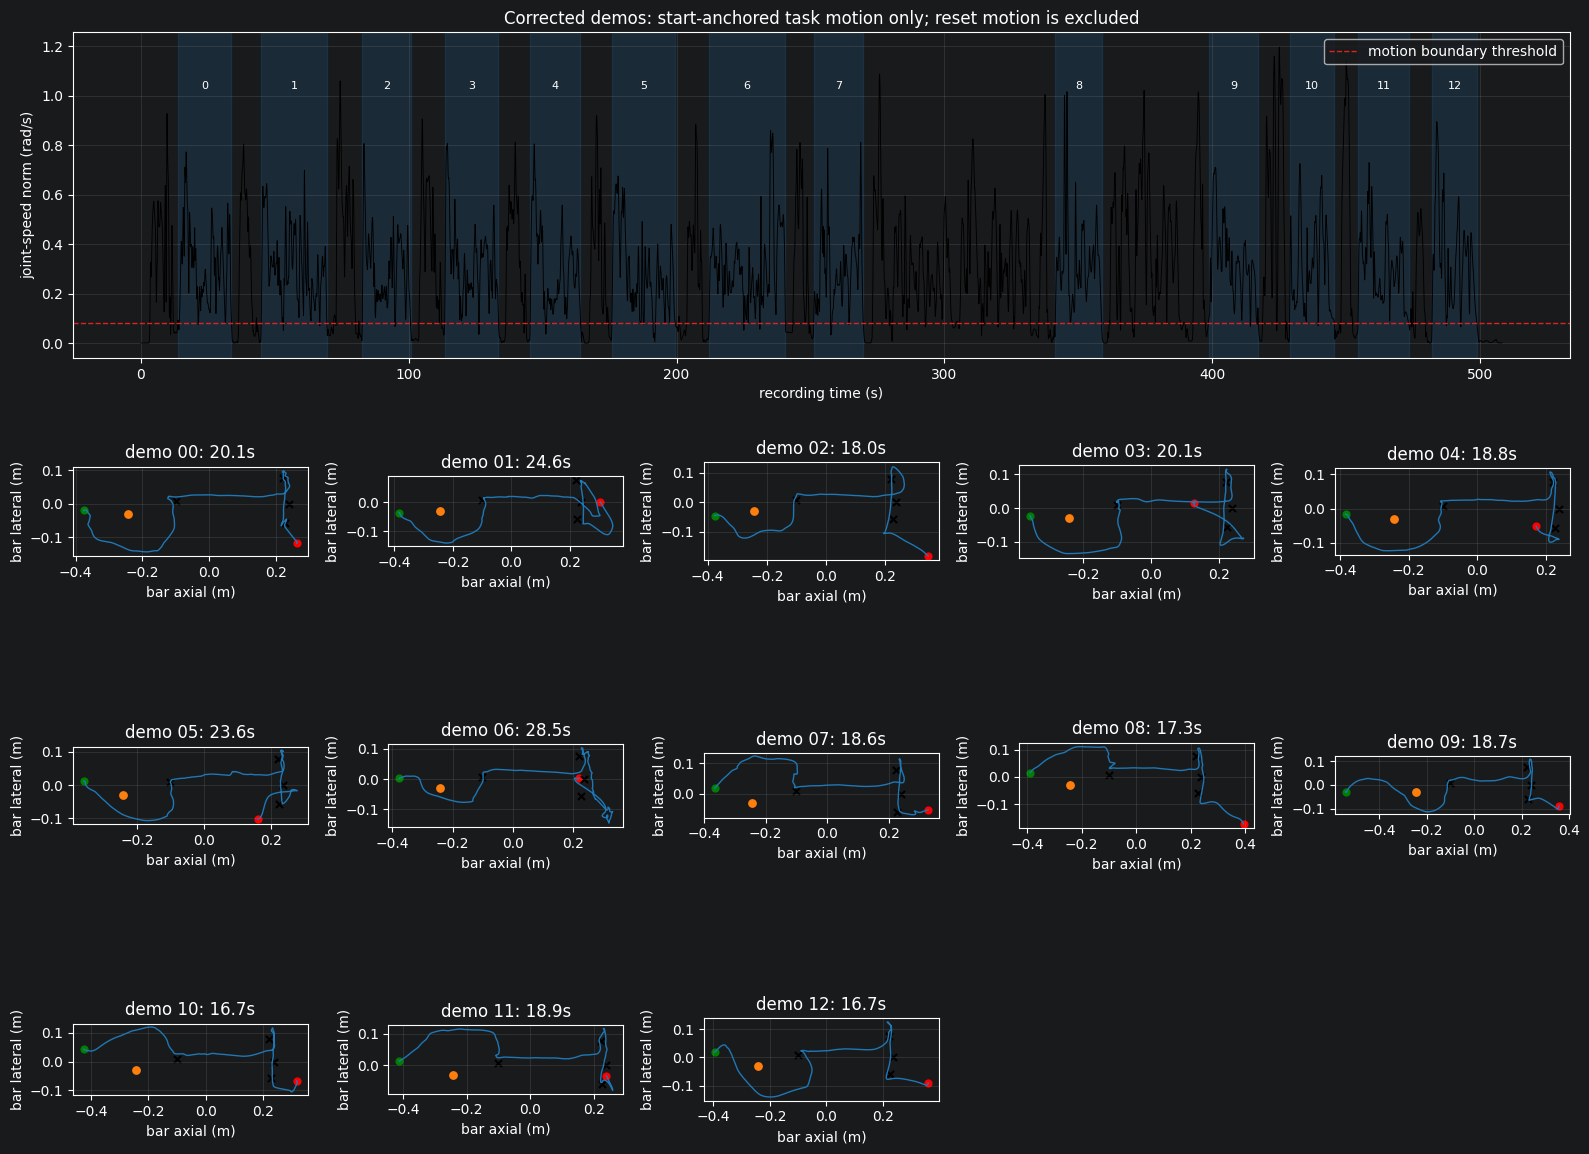

{'validated_demo_count': 13, 'aggregate_samples': 5210, 'all_numeric_values_finite': True, 'all_starts_obstacle_near_bar_left': True, 'return_motion_excluded': True, 'output_size_mb': 3.255, 'preview': '/home/baiyu/LearnStageConstraints/robot/stage_cons_iiwa14/data/processed/demo_r02_auto/segmentation_preview.png'}


In [28]:
saved_manifest = json.loads((OUTPUT / 'manifest.json').read_text())
with np.load(aggregate_path) as saved:
    bounds = saved['demo_bounds_indices']
    ids = saved['demo_id']
    finite = all(
        np.isfinite(saved[key]).all()
        for key in saved.files
        if saved[key].dtype.kind in 'fiu'
    )
    assert bounds.shape == (len(demo_bounds), 2)
    assert saved['demo_bar_poses_optitrack'].shape == (len(demo_bounds), 7)
    assert saved['demo_obstacle_poses_optitrack'].shape == (len(demo_bounds), 7)
    assert finite
    for demo_id, (lo, hi) in enumerate(bounds):
        assert np.all(ids[lo:hi] == demo_id)
        assert hi > lo

per_demo_files = sorted(per_demo_dir.glob('demo_*.npz'))
assert len(per_demo_files) == len(demo_bounds) == 13
assert saved_manifest['selected_demo_count'] == 13
assert np.all(task_xyz[demo_bounds[:, 0], 0] < -0.34)
assert np.all(
    np.linalg.norm(
        task_xyz[demo_bounds[:, 0], :2] - obs_task[:2],
        axis=1,
    ) < 0.32
)
for demo_id, ((a, b), hits) in enumerate(zip(demo_bounds, endpoint_hits)):
    assert np.all(np.diff(hits) >= 0)
    assert hits[-1] < b
    assert qdot_norm[a - 1] < boundary_speed_threshold <= qdot_norm[a]
    assert qdot_norm[b - 1] >= stop_speed_threshold > qdot_norm[b]
    if demo_id + 1 < len(demo_bounds):
        assert b < demo_bounds[demo_id + 1, 0]

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(4, 5, height_ratios=[1.35, 1, 1, 1])
ax_speed = fig.add_subplot(gs[0, :])
ax_speed.plot(grid_s, qdot_norm, color='black', lw=0.65)
ax_speed.axhline(
    stop_speed_threshold,
    color='tab:red',
    ls='--',
    lw=1,
    label='motion boundary threshold',
)
for demo_id, (a, b) in enumerate(demo_bounds):
    ax_speed.axvspan(grid_s[a], grid_s[b - 1], color='tab:blue', alpha=0.18)
    ax_speed.text(
        (grid_s[a] + grid_s[b - 1]) / 2,
        1.02,
        str(demo_id),
        ha='center',
        va='bottom',
        fontsize=8,
    )
ax_speed.set(
    xlabel='recording time (s)',
    ylabel='joint-speed norm (rad/s)',
    title='Corrected demos: start-anchored task motion only; reset motion is excluded',
)
ax_speed.grid(alpha=0.2)
ax_speed.legend(loc='upper right')

for panel in range(15):
    ax = fig.add_subplot(gs[1 + panel // 5, panel % 5])
    if panel >= len(demo_bounds):
        ax.set_visible(False)
        continue
    a, b = demo_bounds[panel]
    xyz = task_xyz[a:b]
    ax.plot(xyz[:, 0], xyz[:, 1], color='tab:blue', lw=1)
    ax.scatter(xyz[0, 0], xyz[0, 1], c='green', s=24, label='start')
    ax.scatter(xyz[-1, 0], xyz[-1, 1], c='red', s=24, label='end')
    ax.scatter(endpoints[:, 0], endpoints[:, 1], c='black', marker='x', s=26)
    ax.scatter(obs_task[0], obs_task[1], c='tab:orange', marker='o', s=28)
    ax.set_title(f'demo {panel:02d}: {(b-a)/analysis_hz:.1f}s')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.2)
    ax.set_xlabel('bar axial (m)')
    ax.set_ylabel('bar lateral (m)')

fig.tight_layout()
preview_path = OUTPUT / 'segmentation_preview.png'
fig.savefig(preview_path, dpi=160, bbox_inches='tight')
plt.show()

print({
    'validated_demo_count': len(per_demo_files),
    'aggregate_samples': int(bounds[-1, 1]),
    'all_numeric_values_finite': finite,
    'all_starts_obstacle_near_bar_left': True,
    'return_motion_excluded': True,
    'output_size_mb': round(
        sum(path.stat().st_size for path in OUTPUT.rglob('*') if path.is_file()) / 1e6,
        3,
    ),
    'preview': str(preview_path),
})

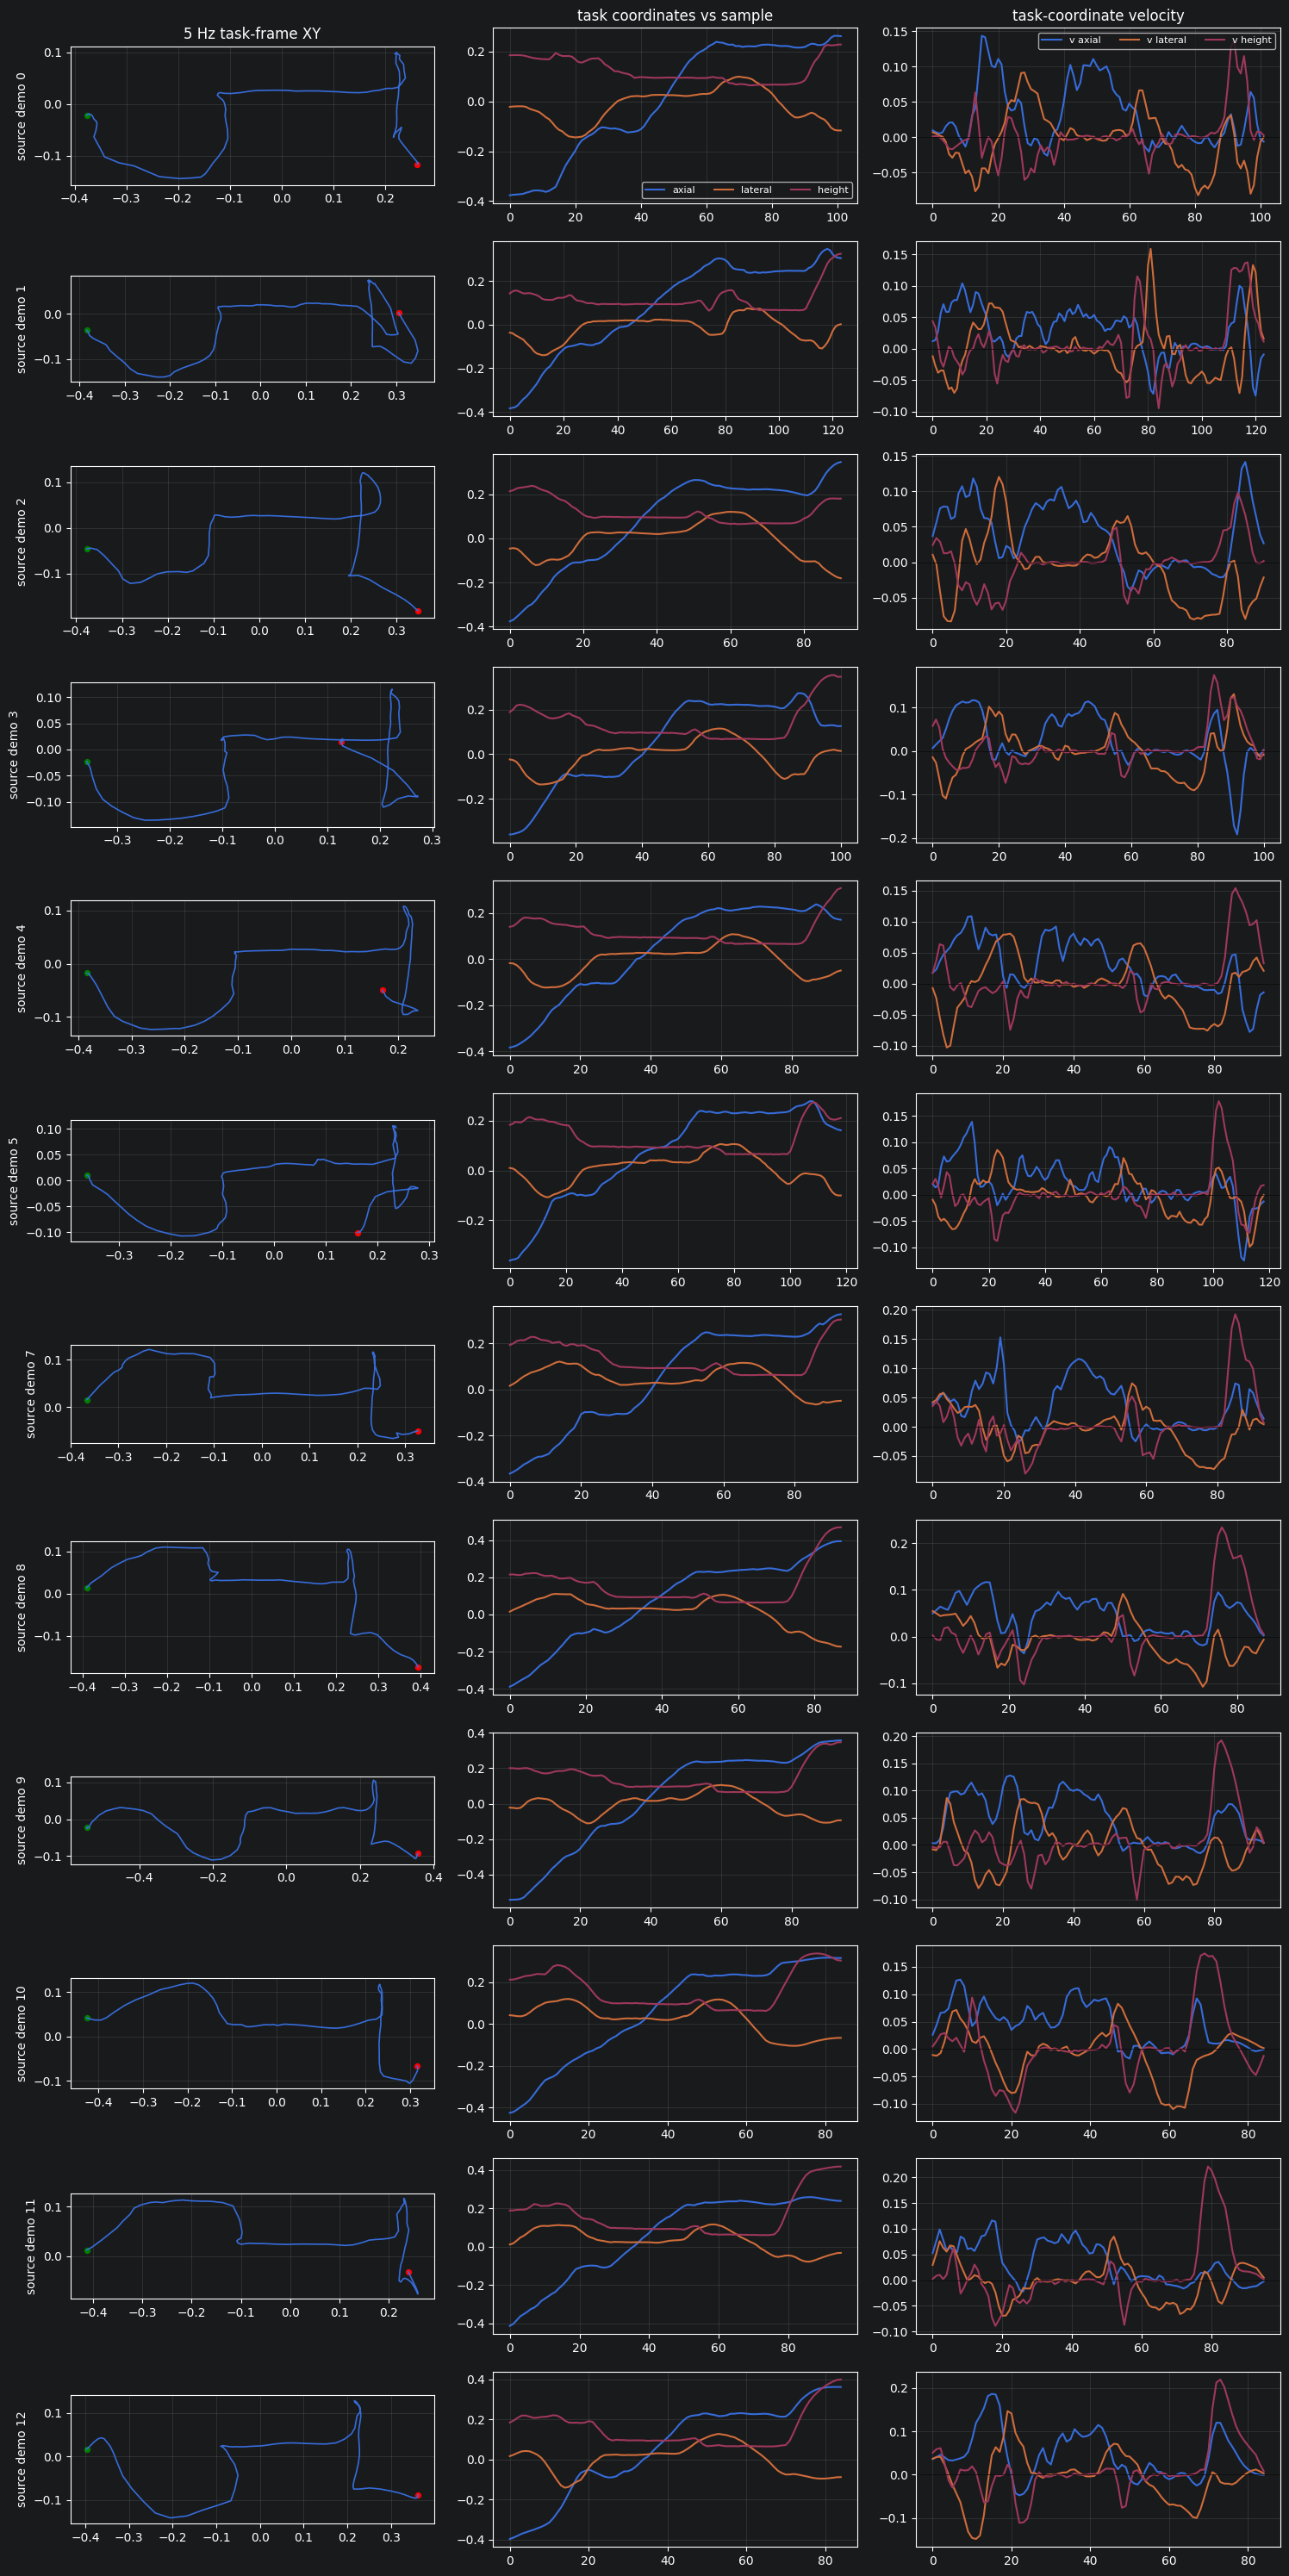

/home/baiyu/LearnStageConstraints/robot/stage_cons_iiwa14/data/processed/demo_r02_auto/barclean_5hz_phase_review.png


In [29]:
fig, axes = plt.subplots(len(bc_5hz), 3, figsize=(15, 2.5 * len(bc_5hz)))
for row, (source_id, trajectory, feature, xyz) in enumerate(bc_5hz):
    sample = np.arange(len(xyz))
    velocity = np.gradient(xyz, 0.2, axis=0)
    axes[row, 0].plot(xyz[:, 0], xyz[:, 1], lw=1.2)
    axes[row, 0].scatter(xyz[0, 0], xyz[0, 1], c='green', s=18)
    axes[row, 0].scatter(xyz[-1, 0], xyz[-1, 1], c='red', s=18)
    axes[row, 0].set_aspect('equal', adjustable='box')
    axes[row, 0].set_ylabel(f'source demo {source_id}')
    axes[row, 0].grid(alpha=0.2)
    axes[row, 1].plot(sample, xyz[:, 0], label='axial')
    axes[row, 1].plot(sample, xyz[:, 1], label='lateral')
    axes[row, 1].plot(sample, xyz[:, 2], label='height')
    axes[row, 1].grid(alpha=0.2)
    axes[row, 2].plot(sample, velocity[:, 0], label='v axial')
    axes[row, 2].plot(sample, velocity[:, 1], label='v lateral')
    axes[row, 2].plot(sample, velocity[:, 2], label='v height')
    axes[row, 2].axhline(0.0, color='black', lw=0.5)
    axes[row, 2].grid(alpha=0.2)
axes[0, 1].legend(ncol=3, fontsize=8)
axes[0, 2].legend(ncol=3, fontsize=8)
axes[0, 0].set_title('5 Hz task-frame XY')
axes[0, 1].set_title('task coordinates vs sample')
axes[0, 2].set_title('task-coordinate velocity')
fig.tight_layout()
phase_review_path = OUTPUT / 'barclean_5hz_phase_review.png'
fig.savefig(phase_review_path, dpi=150, bbox_inches='tight')
plt.show()
print(phase_review_path)